In [1]:
%load_ext autotime

import scarf
scarf.__version__

'1.0.0'

time: 588 ms (started: 2026-06-25 23:40:46 +02:00)


In [2]:
scarf.fetch_dataset(
    dataset_name='tenx_10K_pbmc-v1_atacseq',
    save_path='scarf_datasets'
)

time: 29.5 s (started: 2026-06-25 23:40:46 +02:00)


In [3]:
reader = scarf.CrH5Reader(
    'scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.h5'
)
reader.assayFeats

,ATAC
type,Peaks
start,0
end,89796
nFeatures,89796


time: 28.4 ms (started: 2026-06-25 23:41:16 +02:00)


In [4]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc=f'scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.zarr',
    chunk_size=(1000, 2000)
)
writer.dump(batch_size=1000)

/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=18, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=25, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. 

  0%|                                                                                                         …

time: 21.5 s (started: 2026-06-25 23:41:16 +02:00)


In [5]:
ds = scarf.DataStore(
    'scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.zarr', 
    nthreads=4
)

(ATAC) Computing nCells and dropOuts:   0%|                                                                   …

(ATAC) Computing nCounts:   0%|                                                                               …

(ATAC) Computing nFeatures:   0%|                                                                             …

time: 13.5 s (started: 2026-06-25 23:41:37 +02:00)


INFO: 247 cells flagged for filtering out using attribute ATAC_nCounts


INFO: 294 cells flagged for filtering out using attribute ATAC_nFeatures


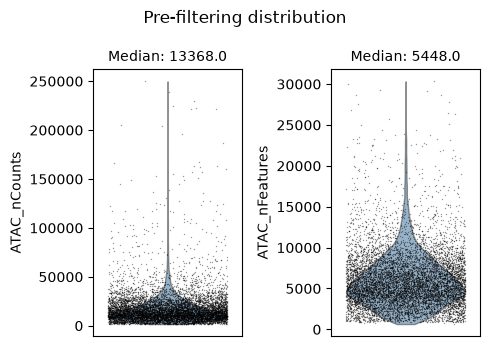

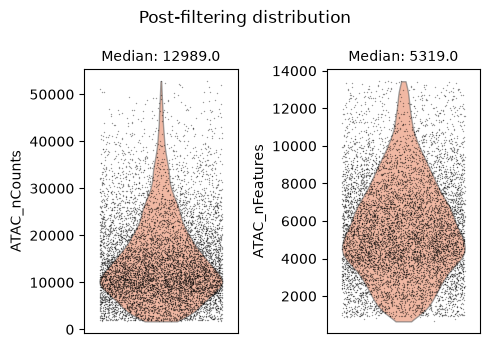

time: 1.76 s (started: 2026-06-25 23:41:51 +02:00)


In [6]:
ds.auto_filter_cells()

In [7]:
ds.mark_prevalent_peaks(top_n=25000)

(ATAC) Calculating peak prevalence across cells:   0%|                                                        …

time: 40.5 s (started: 2026-06-25 23:41:52 +02:00)


In [8]:
ds.ATAC.feats.head()

,I,ids,names,nCells,I__prevalent_peaks,dropOuts,stats_I_prevalence
0,True,chr1:565107-565550,chr1:565107-565550,83,False,8645,0.206181
1,True,chr1:569174-569639,chr1:569174-569639,199,False,8529,0.350725
2,True,chr1:713460-714823,chr1:713460-714823,2486,True,6242,1.993573
3,True,chr1:752422-753038,chr1:752422-753038,432,True,8296,0.680701
4,True,chr1:762106-763359,chr1:762106-763359,1878,True,6850,1.570790


time: 69.9 ms (started: 2026-06-25 23:42:33 +02:00)


In [9]:
ds.make_graph(
    feat_key='prevalent_peaks',
    k=21,
    dims=50,
    n_centroids=100,
    lsi_skip_first=True,
)

Writing data to normed__I__prevalent_peaks/data:   0%|                                                        …

Fitting LSI model:   0%|                                                                                      …

Fitting ANN:   0%|                                                                                            …

Fitting kmeans:   0%|                                                                                         …

Estimating seed partitions:   0%|                                                                             …

Identifying neighbors:   0%|                                                                                  …

Smoothening KNN distances:   0%|                                                                              …

INFO: ANN recall: 99.36%


time: 40.2 s (started: 2026-06-25 23:42:33 +02:00)


In [10]:
ds.run_umap(
    n_epochs=500,
    min_dist=0.1, 
    spread=1, 
    parallel=True
)

Training UMAP:   0%|                                                                                          …

	completed  0  /  500 epochs


	completed  50  /  500 epochs


	completed  100  /  500 epochs


	completed  150  /  500 epochs


...

	completed  350  /  500 epochs


	completed  400  /  500 epochs


	completed  450  /  500 epochs


time: 8.31 s (started: 2026-06-25 23:43:13 +02:00)


/home/parashar/scarf/scarf/metadata.py:337: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)


In [11]:
ds.run_leiden_clustering(resolution=0.6)

time: 1.05 s (started: 2026-06-25 23:43:22 +02:00)


In [12]:
ds.cells.head()

,I,ids,names,ATAC_UMAP2,ATAC_nFeatures,ATAC_nCounts,ATAC_leiden_cluster,ATAC_UMAP1
0,True,AAACGAAAGAGCGAAA-1,AAACGAAAGAGCGAAA-1,-12.991514,5546.0,13187.0,1,-0.916287
1,True,AAACGAAAGAGTTTGA-1,AAACGAAAGAGTTTGA-1,-15.194257,6586.0,16074.0,4,1.873813
2,True,AAACGAAAGCGAGCTA-1,AAACGAAAGCGAGCTA-1,1.768229,9214.0,28009.0,7,-2.853764
3,False,AAACGAAAGGCTTCGC-1,AAACGAAAGGCTTCGC-1,NaN,30325.0,221747.0,-1,NaN
4,True,AAACGAAAGTGCTGAG-1,AAACGAAAGTGCTGAG-1,-12.840392,4922.0,11440.0,1,-1.637857


time: 64.7 ms (started: 2026-06-25 23:43:23 +02:00)


/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


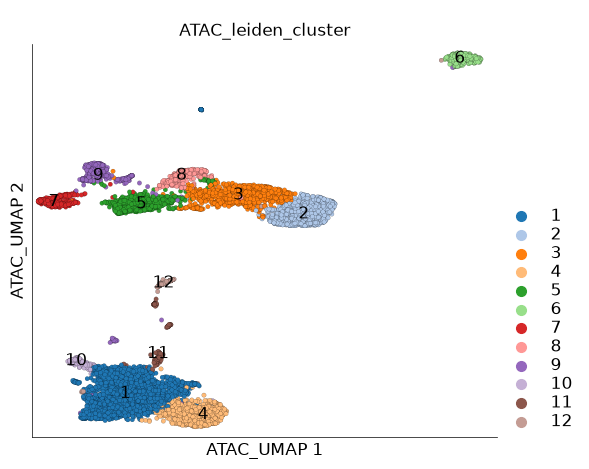

time: 256 ms (started: 2026-06-25 23:43:23 +02:00)


In [13]:
ds.plot_layout(
    layout_key='ATAC_UMAP', 
    color_by='ATAC_leiden_cluster'
)

In [14]:
scarf.fetch_dataset(
    dataset_name='annotations', 
    save_path='scarf_datasets'
)

time: 9.83 s (started: 2026-06-25 23:43:23 +02:00)


In [15]:
ds.add_melded_assay(
    from_assay='ATAC',
    external_bed_fn='scarf_datasets/annotations/human_GRCh37_gencode_v38_gene_body.bed.gz',
    peaks_col='ids',
    renormalization=False,
    assay_label='GeneScores',
    assay_type='RNA'
)

INFO: 33898/62409 features did not overlap with any peak


/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=22, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=25, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. 

  0%|                                                                                                         …

(GeneScores) Computing nCells and dropOuts:   0%|                                                             …

(GeneScores) Computing nCounts:   0%|                                                                         …

(GeneScores) Computing nFeatures:   0%|                                                                       …

(GeneScores) Computing GeneScores_percentMito:   0%|                                                          …

(GeneScores) Computing GeneScores_percentRibo:   0%|                                                          …

time: 1min 10s (started: 2026-06-25 23:43:33 +02:00)


In [16]:
ds

DataStore has 8426 (8728) cells with 2 assays: GeneScores ATAC
   Cell metadata:
            'I', 'ids', 'names', 'GeneScores_percentMito', 'ATAC_leiden_cluster', 
            'ATAC_nFeatures', 'ATAC_UMAP2', 'GeneScores_percentRibo', 'GeneScores_nFeatures', 'GeneScores_nCounts', 
            'ATAC_UMAP1', 'ATAC_nCounts'
   ATAC assay has 86049 (89796) features and following metadata:
            'I', 'ids', 'names', 'I__prevalent_peaks', 'dropOuts', 
            'nCells'
   GeneScores assay has 28357 (62409) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

time: 72.3 ms (started: 2026-06-25 23:44:43 +02:00)


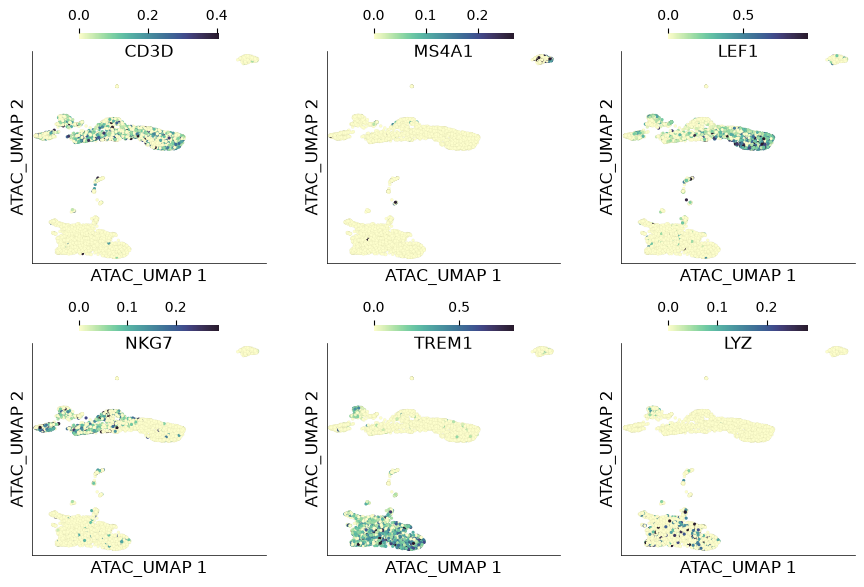

time: 34.3 s (started: 2026-06-25 23:44:43 +02:00)


In [17]:
ds.plot_layout(
    layout_key='ATAC_UMAP', from_assay='GeneScores', 
    color_by=['CD3D', 'MS4A1', 'LEF1', 'NKG7', 'TREM1', 'LYZ'],
    clip_fraction=0.01, 
    n_columns=3,
    width=3,
    height=3,
    point_size=5,
    scatter_kwargs={'lw': 0.01},
)